In [1]:
# import all the lib
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [3]:
data = pd.read_csv('alexbizer.csv')

In [4]:
data.head()

,fixed_acidity,volatile_acidity,citric_acid,residual_sugar,chlorides,free_sulfur_dioxide,density,pH,sulphates,alcohol,bound_sulfur_dioxide,quality_class
0,7.0,0.27,0.36,20.7,0.045,45.0,1.0010,3.00,0.45,8.8,125.0,1
1,6.3,0.30,0.34,1.6,0.049,14.0,0.9940,3.30,0.49,9.5,118.0,1
2,8.1,0.28,0.40,6.9,0.050,30.0,0.9951,3.26,0.44,10.1,67.0,1
3,7.2,0.23,0.32,8.5,0.058,47.0,0.9956,3.19,0.40,9.9,139.0,1
4,7.2,0.23,0.32,8.5,0.058,47.0,0.9956,3.19,0.40,9.9,139.0,1


In [5]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3989 entries, 0 to 3988
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed_acidity         3989 non-null   float64
 1   volatile_acidity      3989 non-null   float64
 2   citric_acid           3989 non-null   float64
 3   residual_sugar        3989 non-null   float64
 4   chlorides             3989 non-null   float64
 5   free_sulfur_dioxide   3989 non-null   float64
 6   density               3989 non-null   float64
 7   pH                    3989 non-null   float64
 8   sulphates             3989 non-null   float64
 9   alcohol               3989 non-null   float64
 10  bound_sulfur_dioxide  3989 non-null   float64
 11  quality_class         3989 non-null   int64  
dtypes: float64(11), int64(1)
memory usage: 374.1 KB


In [7]:
data.describe()

,fixed_acidity,volatile_acidity,citric_acid,residual_sugar,chlorides,free_sulfur_dioxide,density,pH,sulphates,alcohol,bound_sulfur_dioxide,quality_class
count,3989.000000,3989.000000,3989.000000,3989.000000,3989.000000,3989.000000,3989.000000,3989.000000,3989.000000,3989.000000,3989.000000,3989.000000
mean,6.812196,0.264077,0.324297,6.361782,0.042280,34.751943,0.993844,3.187132,0.480657,10.589215,101.540737,0.937328
std,0.736644,0.076218,0.086161,4.925209,0.009934,15.026834,0.002883,0.138236,0.099087,1.214312,32.977049,0.729850
min,4.800000,0.080000,0.100000,0.600000,0.015000,2.000000,0.987110,2.820000,0.220000,8.400000,14.000000,0.000000
25%,6.300000,0.210000,0.270000,1.800000,0.035000,24.000000,0.991580,3.090000,0.410000,9.500000,77.000000,0.000000
50%,6.800000,0.260000,0.310000,5.200000,0.042000,34.000000,0.993500,3.180000,0.470000,10.500000,98.000000,1.000000
75%,7.300000,0.310000,0.370000,9.700000,0.049000,45.000000,0.995870,3.280000,0.540000,11.400000,124.000000,1.000000
max,8.800000,0.485000,0.570000,22.000000,0.071000,80.000000,1.001960,3.560000,0.760000,14.200000,195.500000,2.000000


<Figure size 864x432 with 0 Axes>

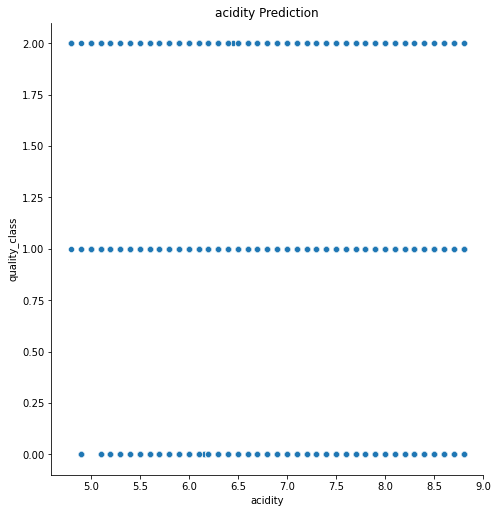

In [6]:
plt.figure(figsize=(12,6))
sns.pairplot(data,x_vars=['fixed_acidity'],y_vars=['quality_class'],height=7,kind='scatter')
plt.xlabel('acidity')
plt.ylabel('quality_class')
plt.title('acidity Prediction')
plt.show()

In [8]:
X = data['fixed_acidity']
X.head()

0    7.0
1    6.3
2    8.1
3    7.2
4    7.2
Name: fixed_acidity, dtype: float64

In [9]:
y = data['quality_class']
y.head()

0    1
1    1
2    1
3    1
4    1
Name: quality_class, dtype: int64

In [10]:
from sklearn.model_selection import train_test_split

In [11]:
X_train,X_test,y_train,y_test = train_test_split(X,y,train_size=0.7,random_state=100)

In [12]:
X_train = X_train[:,np.newaxis]
X_test = X_test[:,np.newaxis]

C:\Users\ALEX_A~1\AppData\Local\Temp/ipykernel_76408/2733214152.py:1: FutureWarning: Support for multi-dimensional indexing (e.g. `obj[:, None]`) is deprecated and will be removed in a future version.  Convert to a numpy array before indexing instead.
  X_train = X_train[:,np.newaxis]
C:\Users\ALEX_A~1\AppData\Local\Temp/ipykernel_76408/2733214152.py:2: FutureWarning: Support for multi-dimensional indexing (e.g. `obj[:, None]`) is deprecated and will be removed in a future version.  Convert to a numpy array before indexing instead.
  X_test = X_test[:,np.newaxis]


In [13]:
from sklearn.linear_model import LinearRegression

In [14]:
lr = LinearRegression()
lr.fit(X_train,y_train)

LinearRegression()

In [15]:
y_pred = lr.predict(X_test)

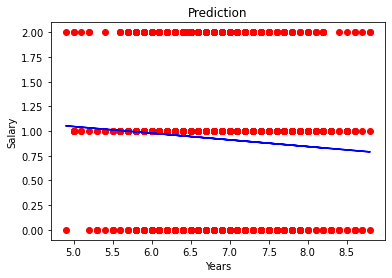

In [16]:
plt.scatter(X_test,y_test,color='r')
plt.plot(X_test,y_pred,color='b',linestyle='-')
plt.xlabel('Years')
plt.ylabel('Salary')
plt.title('Prediction')
plt.show()

In [17]:
from sklearn.metrics import r2_score,mean_squared_error,mean_absolute_error

In [18]:
mse = mean_squared_error(y_test,y_pred)
mae = mean_absolute_error(y_test,y_pred)

In [19]:
rsq = r2_score(y_test,y_pred)

In [20]:
print('mean squared error :',mse)
print('mean absolute error :',mae)
print('r square :',rsq)

mean squared error : 0.5271809903495176
mean absolute error : 0.5605085989043829
r square : -0.005267114371329207


In [21]:
print('Intercept of the model:',lr.intercept_)
print('Coefficient of the line:',lr.coef_)

Intercept of the model: 1.384053463171992
Coefficient of the line: [-0.06756082]
